## Bài toán dự đoán giá nhà
- Đưa vào các thuộc tính căn nhà dự đoán giá (price)

### Bài tập
- Tiền xử lý dữ liệu cho trước: dữ liệu dự đoán giá nhà (xem thêm tại https://www.kaggle.com/harlfoxem/housesalesprediction)
- Xây dựng và đánh giá các mô hình KNN, Random Forest, Linear Regression, Ridge, Lasso
- Lựa chọn các siêu tham số cho từng mô hình
- So sánh các mô hình với nhau

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('kc_house_data.csv')
print(df.shape)        # (21613, 21)
print(df.info())
print(df.describe())

(21613, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64

In [7]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


## Preprocessing

In [6]:
df = df.drop(['id', 'date'], axis=1)
print(df.isnull().sum())

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [8]:
df['house_age'] = 2015 - df['yr_built']
df['renovated'] = (df['yr_renovated'] > 0).astype(int)
df['basement']        = (df['sqft_basement'] > 0).astype(int)
df['total_sqft']      = df['sqft_living'] + df['sqft_above'] + df['sqft_basement']
df['rooms_per_floor'] = df['bedrooms'] / (df['floors'] + 1e-9)

df= df.drop(columns=['yr_built','yr_renovated'])

df = df[df['price'] < 5000000]

In [9]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,renovated,basement,total_sqft,rooms_per_floor
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,98178,47.5112,-122.257,1340,5650,60,0,0,2360,3.0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,98125,47.7210,-122.319,1690,7639,64,1,1,5140,1.5
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,98028,47.7379,-122.233,2720,8062,82,0,0,1540,2.0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,98136,47.5208,-122.393,1360,5000,50,0,1,3920,4.0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,98074,47.6168,-122.045,1800,7503,28,0,0,3360,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,...,98103,47.6993,-122.346,1530,1509,6,0,0,3060,1.0
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,...,98146,47.5107,-122.362,1830,7200,1,0,0,4620,2.0
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,...,98144,47.5944,-122.299,1020,2007,6,0,0,2040,1.0
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,...,98027,47.5345,-122.069,1410,1287,11,0,0,3200,1.5


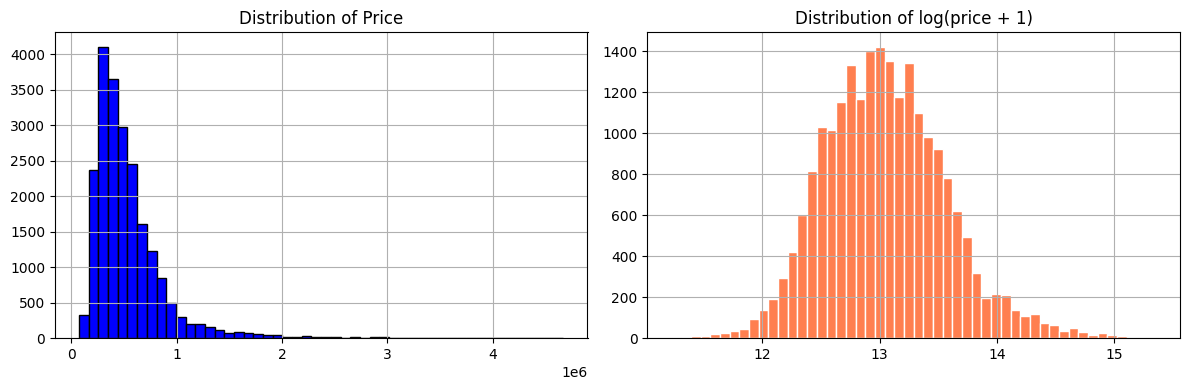

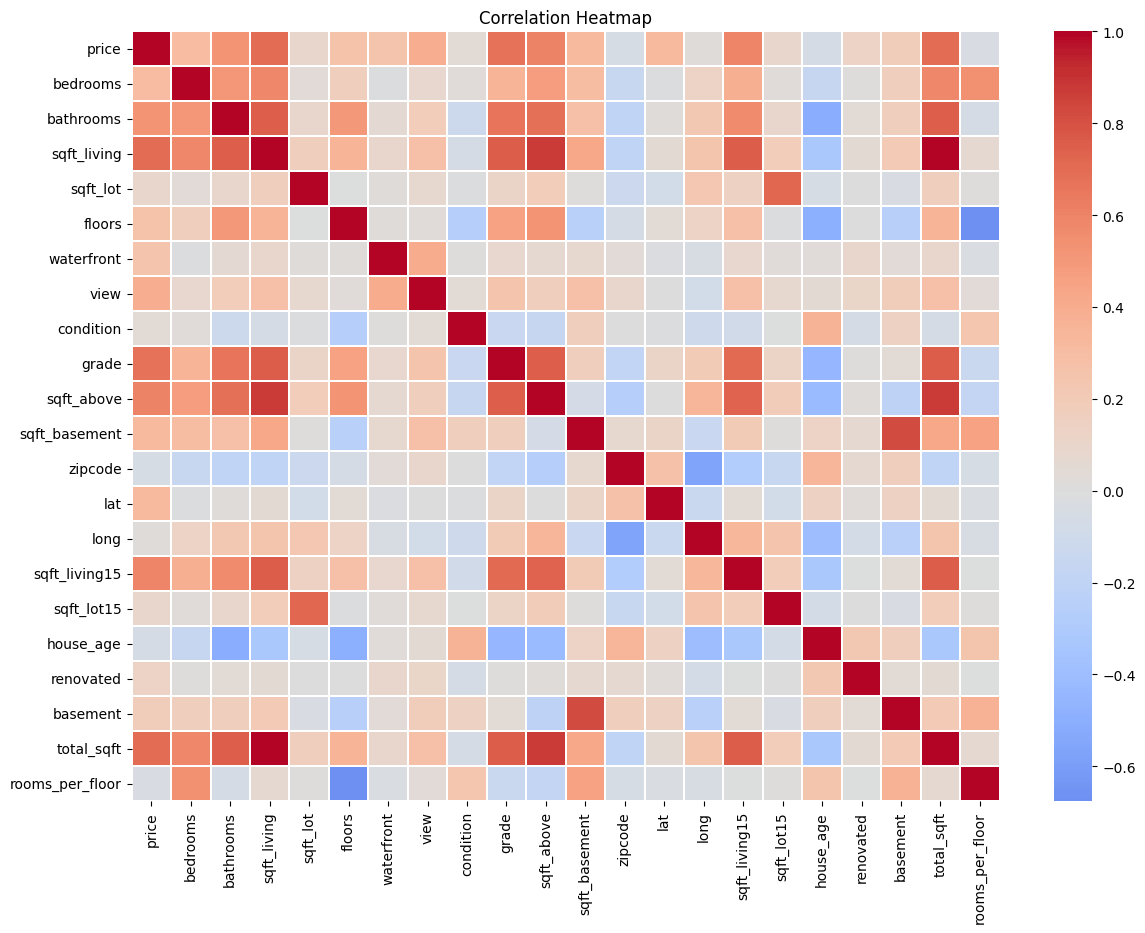

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price'].hist(bins=50, ax=axes[0],color='blue',edgecolor='black')
axes[0].set_title('Distribution of Price')

np.log1p(df['price']).hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribution of log(price + 1)')
plt.tight_layout(); plt.show()

# ── 2.6 Correlation heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap'); plt.show()

Scaling

In [11]:
X = df.drop(columns=['price'])
y = np.log1p(df['price'])  # log-transform để cải thiện R²

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (17284, 21) | Test: (4322, 21)


In [12]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    """Trả về dict chứa các chỉ số, in kết quả."""
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)

    # Cross-validation R² trên tập train
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  R²    : {r2:.4f}")
    print(f"  CV R² : {cv_r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_R2': cv_r2}

Built & training models

In [13]:
results = []
# linear Reg
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
results.append(evaluate("Linear Regression", lr, X_train_sc, X_test_sc, y_train, y_test))

ridge_params = {'alpha': [0.01,0.1,1,10,100,500]}
ridge_gs = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_gs.fit(X_train_sc, y_train)
print(f"Best Ridge alpha: {ridge_gs.best_params_['alpha']}")
results.append(evaluate("Ridge Regression", ridge_gs.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))  

lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}
lasso_gs = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_gs.fit(X_train_sc, y_train)
print("Lasso best alpha:", lasso_gs.best_params_)
results.append(evaluate('Lasso', lasso_gs.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

knn_params = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights':     ['uniform', 'distance'],
    'p':           [1, 2]             # 1=Manhattan, 2=Euclidean
}
knn_gs = GridSearchCV(KNeighborsRegressor(), knn_params, cv=5, scoring='r2', n_jobs=-1)
knn_gs.fit(X_train_sc, y_train)
print("KNN best params:", knn_gs.best_params_)
results.append(evaluate('KNN', knn_gs.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}
rf_gs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, n_iter=30, cv=5, scoring='r2', n_jobs=-1, random_state=42
)
rf_gs.fit(X_train, y_train)   # RF không cần scale
print("RF best params:", rf_gs.best_params_)




  Linear Regression
  RMSE  : 0.2558
  MAE   : 0.1963
  R²    : 0.7616
  CV R² : 0.7722
Best Ridge alpha: 100

  Ridge Regression
  RMSE  : 0.2559
  MAE   : 0.1964
  R²    : 0.7615
  CV R² : 0.7722
Lasso best alpha: {'alpha': 0.001}

  Lasso
  RMSE  : 0.2559
  MAE   : 0.1963
  R²    : 0.7614
  CV R² : 0.7723
KNN best params: {'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}

  KNN
  RMSE  : 0.2137
  MAE   : 0.1554
  R²    : 0.8337
  CV R² : 0.8345
RF best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30}


In [14]:
results_rf = rf_gs.best_estimator_
y_pred_rf  = results_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
cv_rf   = cross_val_score(results_rf, X_train, y_train, cv=5, scoring='r2').mean()
print(f"\nRandom Forest | RMSE={rmse_rf:.4f} | MAE={mae_rf:.4f} | R²={r2_rf:.4f} | CV R²={cv_rf:.4f}")
results.append({'Model': 'Random Forest', 'RMSE': rmse_rf, 'MAE': mae_rf, 'R2': r2_rf, 'CV_R2': cv_rf})



Random Forest | RMSE=0.1736 | MAE=0.1229 | R²=0.8903 | CV R²=0.8852



                      RMSE     MAE      R2   CV_R2
Model                                            
Random Forest      0.1736  0.1229  0.8903  0.8852
KNN                0.2137  0.1554  0.8337  0.8345
Linear Regression  0.2558  0.1963  0.7616  0.7722
Ridge Regression   0.2559  0.1964  0.7615  0.7722
Lasso              0.2559  0.1963  0.7614  0.7723


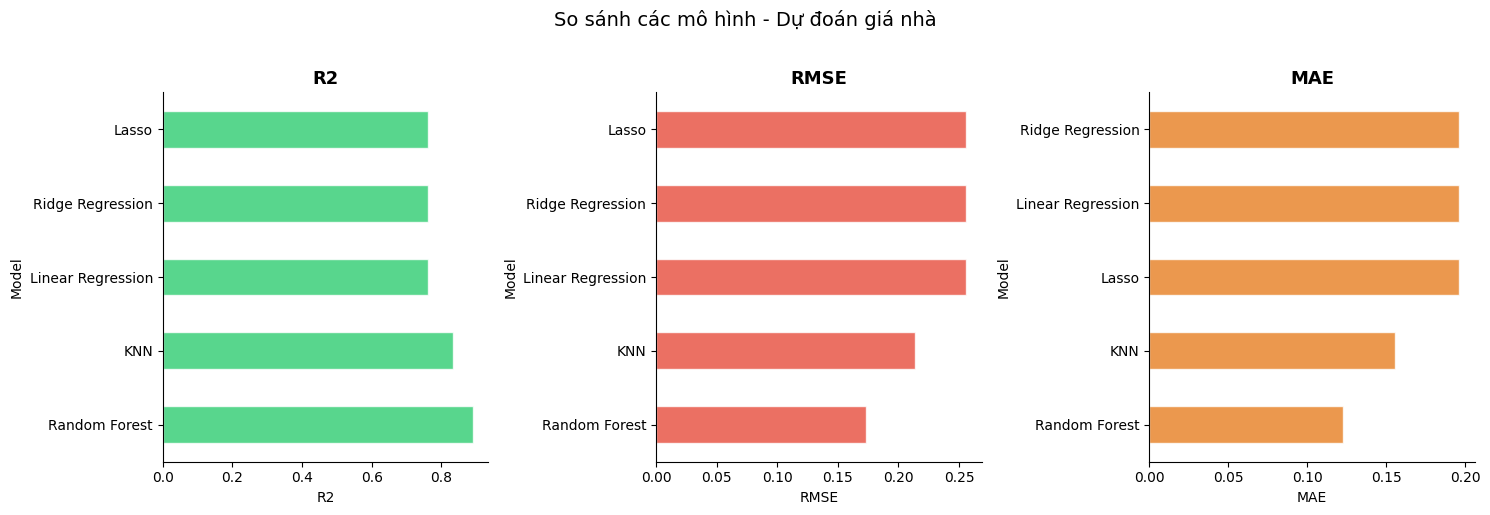

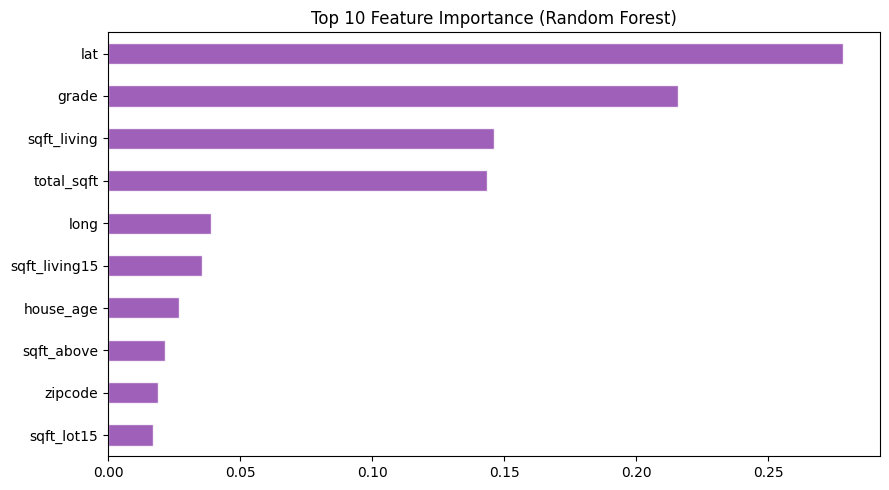

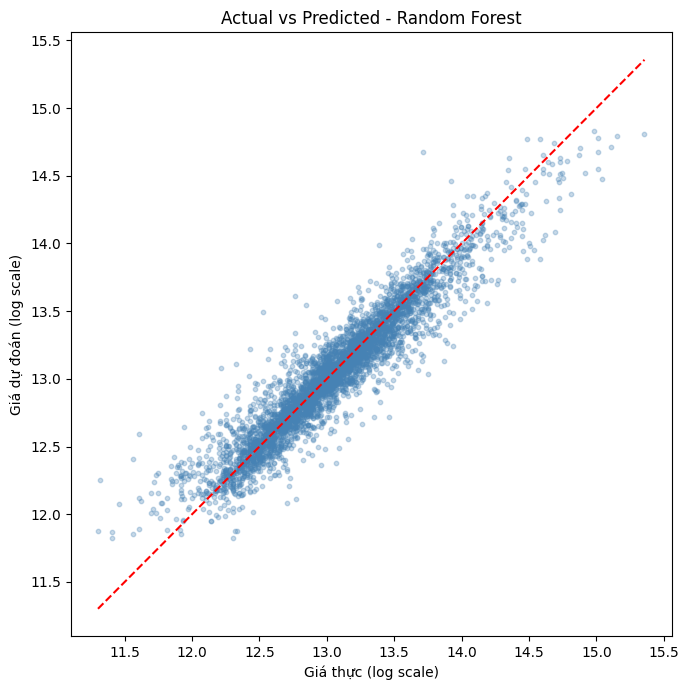

In [15]:
results_df = pd.DataFrame(results).set_index('Model')
print("\n", results_df.sort_values('R2', ascending=False).round(4))

# ── Biểu đồ so sánh ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R2', 'RMSE', 'MAE']
colors  = ['#2ecc71', '#e74c3c', '#e67e22']

for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].sort_values(ascending=(metric != 'R2')).plot(
        kind='barh', ax=ax, color=color, alpha=0.8, edgecolor='white'
    )
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.suptitle('So sánh các mô hình - Dự đoán giá nhà', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# ── Feature Importance (Random Forest) ───────────────────────────────────────
feat_imp = pd.Series(
    rf_gs.best_estimator_.feature_importances_, index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='#8e44ad', alpha=0.85, edgecolor='white')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

# ── Actual vs Predicted (mô hình tốt nhất) ───────────────────────────────────
y_pred_best = rf_gs.best_estimator_.predict(X_test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Giá thực (log scale)'); plt.ylabel('Giá dự đoán (log scale)')
plt.title('Actual vs Predicted - Random Forest')
plt.tight_layout(); plt.show()